# oasis3 full preprocessing driver

this driver runs the shared preprocessing and saves anonymous aggregate qc information plus no more than three visual qc examples.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / 'SkullStrippingProject']
PROJECT_ROOT = next(path for path in candidates if (path / 'src' / 'skullstrip_pipeline').exists())
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from skullstrip_pipeline.driver import run_dataset
from skullstrip_pipeline.reporting import build_dataset_qc_report, save_anonymous_qc_examples, save_dataset_qc_summary_plot

DATASET = 'OASIS3'
MAX_FILES = None
REPLACE = False
SAVE_QC_PLOTS = True
MAX_QC_PLOTS = 3
GPU_PHYSICAL_ID = 1
RUN_PREPROCESSING = False

print(f'{DATASET.lower()} settings: run preprocessing={RUN_PREPROCESSING}, max files={MAX_FILES}, replace={REPLACE}, gpu={GPU_PHYSICAL_ID}')


oasis3 settings: run preprocessing=False, max files=None, replace=False, gpu=1


## preprocessing


In [2]:
if RUN_PREPROCESSING:
    status = run_dataset(
        DATASET,
        max_files=MAX_FILES,
        replace=REPLACE,
        save_qc_plots=SAVE_QC_PLOTS,
        max_qc_plots=MAX_QC_PLOTS,
        gpu_physical_id=GPU_PHYSICAL_ID,
        progress=True,
    )
else:
    manifest_path = PROJECT_ROOT.parent / 'Processed' / 'MRI' / DATASET / 'manifests' / f'{DATASET.lower()}_preprocessing_manifest.csv'
    status = pd.read_csv(manifest_path, low_memory=False)
    print(f'{DATASET.lower()} report-only mode: loaded {len(status)} manifest rows without reprocessing')


oasis3 report-only mode: loaded 4116 manifest rows without reprocessing


## qc report and sanity checks


In [3]:
qc_report = build_dataset_qc_report(status)

print('manifest status')
display(qc_report['status'])
print('stage qc summary')
display(qc_report['stage_qc'])
print('final-output sanity checks')
display(qc_report['sanity_checks'])
print('qc metric distribution for successful scans')
display(qc_report['metric_summary'])
print('final spatial geometry')
display(qc_report['geometry'])

if not qc_report['failures'].empty:
    print('anonymous failure summary')
    display(qc_report['failures'])
else:
    print('anonymous failure summary: no failures')


manifest status


,status,count,percent
0,success,4106,99.76
1,qc_failed,10,0.24


stage qc summary


,stage,passed,failed,not_evaluated,pass_rate_percent
0,SynthStrip brain mask,4113,3,0,99.93
1,mask-guided N4,4113,3,0,99.93
2,native skull stripping,4113,3,0,99.93
3,affine MNI registration,4106,10,0,99.76
4,brain-masked Z-score,4106,10,0,99.76


final-output sanity checks


...

,metric,unit,count,median,p05,p95,minimum,maximum,target
0,brain-mask volume,mL,4106,1479.773438,956.528125,1775.738857,692.047500,2039.905739,150 to 2500
1,template overlap,fraction,4106,0.982448,0.894262,0.995880,0.850236,0.999951,>= 0.85
2,centroid distance,mm,4106,2.412184,0.748499,11.872926,0.069938,27.809813,<= 30
3,normalized brain mean,Z,4106,0.000000,-0.000000,0.000000,-0.000000,0.000000,about 0
4,normalized brain standard deviation,Z,4106,1.000000,1.000000,1.000000,1.000000,1.000000,about 1
5,normalized background maximum,absolute Z,4106,0.000000,0.000000,0.000000,0.000000,0.000000,0


final spatial geometry


,property,value,count
0,final shape,182x218x182,4106
1,final spacing (mm),1x1x1,4106


anonymous failure summary


,status,error_type,reason,count
0,qc_failed,ValueError,Affine registration output failed automated QC,7
1,qc_failed,ValueError,Source NIfTI failed 3D sanity checks,3


## saved qc plots


aggregate qc plot saved: Processed/MRI/OASIS3/qc_examples/qc_summary.png
anonymous visual qc plots saved: 3 of maximum 3
list_position is the 1-based row number in the dataset preprocessing manifest


,sample_number,list_position,plot_path
0,1,160,Processed/MRI/OASIS3/qc_examples/qc_sample_001...
1,2,1533,Processed/MRI/OASIS3/qc_examples/qc_sample_002...
2,3,3188,Processed/MRI/OASIS3/qc_examples/qc_sample_003...


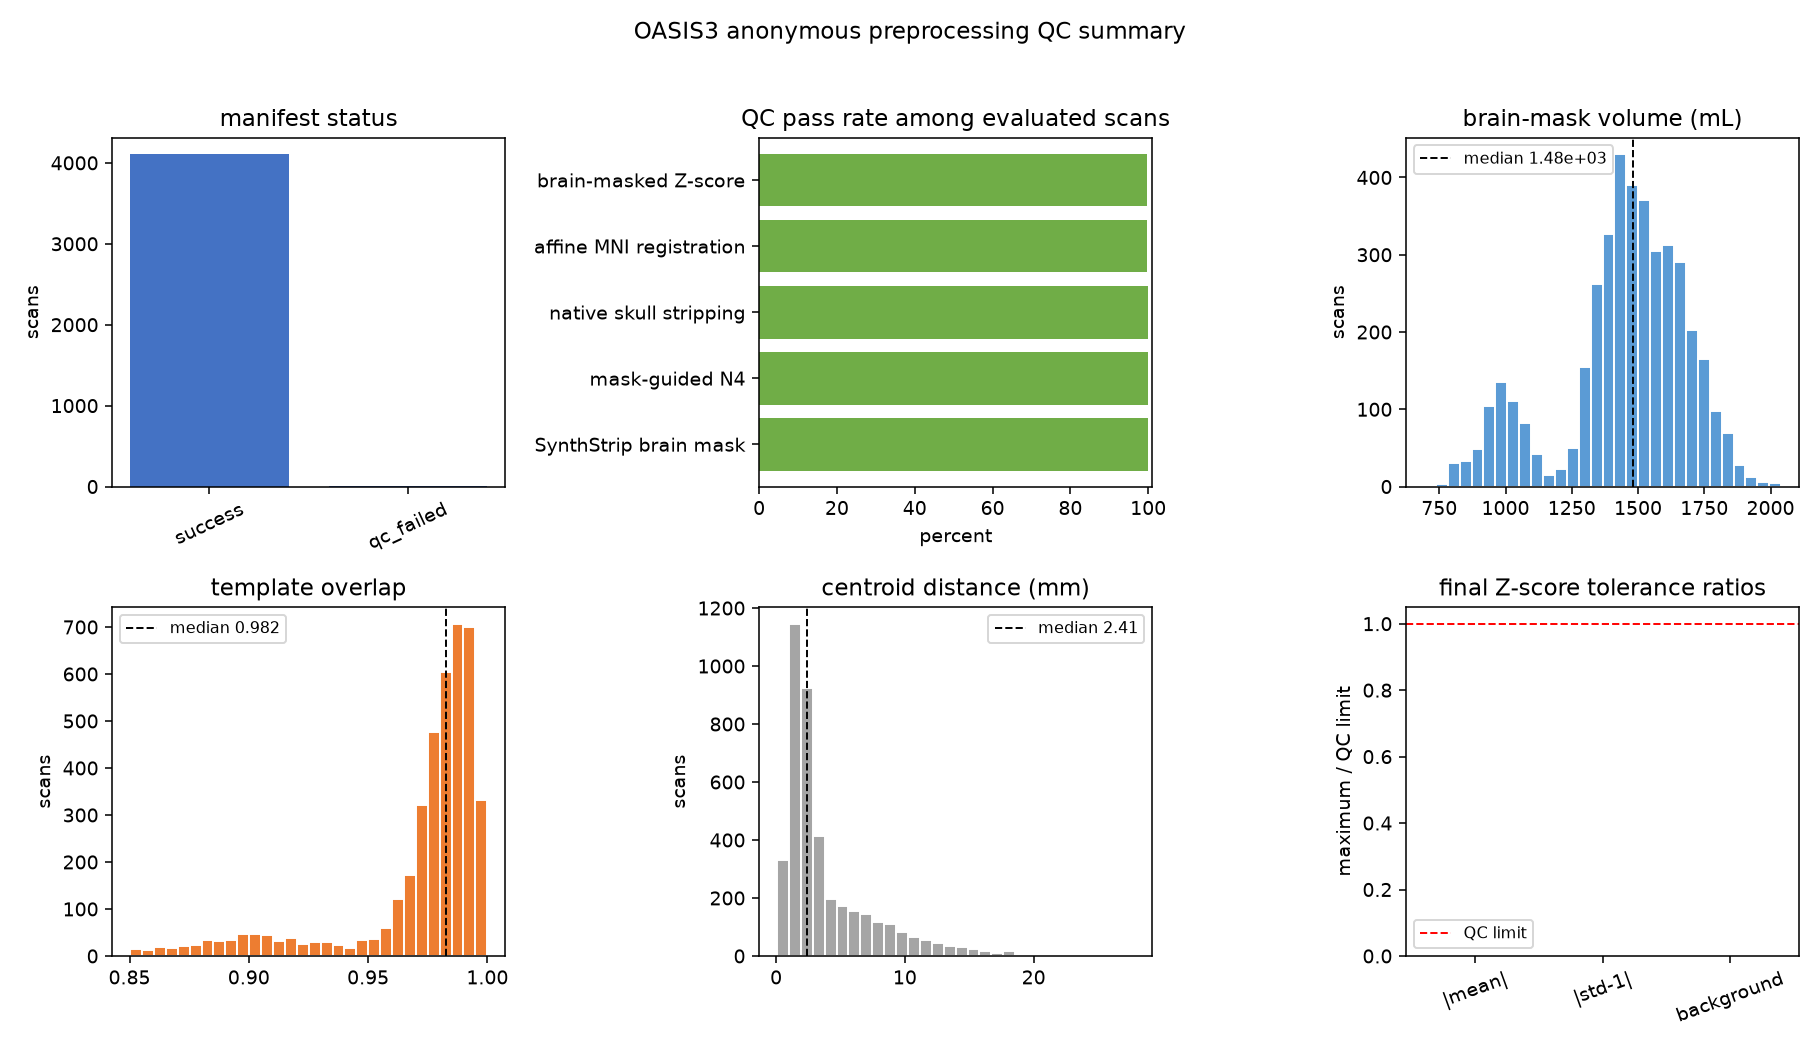

In [4]:
summary_plot = save_dataset_qc_summary_plot(status, DATASET)
visual_selection = save_anonymous_qc_examples(status, DATASET, MAX_QC_PLOTS)

print(f'aggregate qc plot saved: {summary_plot.relative_to(PROJECT_ROOT.parent)}')
print(f'anonymous visual qc plots saved: {len(visual_selection)} of maximum {MAX_QC_PLOTS}')
print('list_position is the 1-based row number in the dataset preprocessing manifest')
display(visual_selection)
display(Image(filename=str(summary_plot)))


## final check


In [5]:
success_count = int(status['status'].eq('success').sum())
failed_count = int(status['status'].isin(['failed', 'qc_failed']).sum())
unfinished_count = int(status['status'].ne('success').sum())
print(f'oasis3 final status: success={success_count} of {len(status)}, unfinished={unfinished_count}, failed={failed_count}')
if unfinished_count and RUN_PREPROCESSING:
    raise RuntimeError(f'oasis3 has {unfinished_count} scans requiring checkpoint retry')
if unfinished_count:
    print('oasis3 report saved with unresolved scans requiring manual review')
else:
    print('oasis3 preprocessing and automated qc finished')


oasis3 final status: success=4106 of 4116, unfinished=10, failed=10
oasis3 report saved with unresolved scans requiring manual review
